In [1]:
import numpy as np
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import IPython.display as display

In [2]:
iris_dataset = load_iris()

In [3]:
size = len(iris_dataset.data)
print(size)

150


In [4]:
# normalize and prepare the dataset
X = iris_dataset.data
x_min = X.min(axis=0)
x_max = X.max(axis=0)
x = (X - x_min) / (x_max - x_min)

In [5]:
# one hot encode the y values
y = iris_dataset.target
y = np.eye(3)[y]

In [6]:
def relu(x):
    return np.maximum(0, x)

In [7]:
class Neuron:
    """Class Neuron which accepts a set of inputs and weights.
    It performs the dot product of the inputs and weights and has it's own activation function (ReLU in our case)
    Each neuron has it's own activation function and we return the activation function output.
    """
    def __init__(self, inputs=[], act='relu') -> None:
        self.input_sources = inputs
        self.inputs = np.array([n() if callable(n) else n for n in inputs])
        self.weights = np.random.random(len(self.inputs))
        self.bias = np.random.random()
        self.gradients = np.array([])
        self.act = act

    def return_dot(self):
        # Compute the summation of products of inputs and weights whenever it's called as a function
        dot_prod = np.dot(self.inputs, self.weights) + self.bias
        return dot_prod
    
    def __call__(self):
        # dynamically recompute inputs from upstream sources
        self.inputs = np.array([n() if callable(n) else n for n in self.input_sources])
        out = self.return_dot()
        if self.act == 'relu':
            out = relu(out)
        elif self.act == 'linear':
            pass
        elif self.act == 'tanh':
            out = np.tanh(out)
        
        return out
    
    def set_input(self, new_inputs):
        self.input_sources = new_inputs
    
    def backward(self,upstream):
        # n = self.__call__()         # n(x)
        dot = self.return_dot()     # f(x) inside the n(x)

        # g is supposed to store the differential of the activation function
        g = 1

        if self.act == 'relu':
            g = 1 if dot > 0 else 0
        elif self.act == 'tanh':
            g = 1 - np.tanh(dot) ** 2

        self.gradients = self.inputs.copy()   # dn/dw = inputs
        # adding a copy to avoid corrupting original inputs
        self.gradients.resize(self.inputs.size + 1)
        self.gradients[-1] =  1      # dn/db = 1

        self.gradients = upstream * g * self.gradients     # now the f'(x) thiing is multiplied
        # self.gradients is [dn/dw0, dn/dw1, .... , dn/db] computed locally

        # another thing to return, the new upstream: loss gradient with respect to neuron output
        new_upstream = upstream * g * self.weights

        return new_upstream

    def step(self, lr):
        self.weights = self.weights - lr * self.gradients[:-1]
        self.bias = self.bias - lr * self.gradients[-1]

    def zero_grad(self):
        # reset the gradients to zero to avoid gradient accummulation
        self.gradients = np.zeros(len(self.weights) + 1)

    
    def __repr__(self):
        # print out weights and inputs
        inputs = f"Inputs: {self.inputs}"
        weights = f"Weights: {self.weights}"
        bias = f"Bias: {self.bias}"

        final = weights + " * " + inputs + " + " + bias

        return final

In [8]:
np.random.seed(0)

hidden = [Neuron(inputs=[0,0,0,0], act='tanh') for _ in range(6)]

output = [Neuron(inputs=hidden, act='linear') for _ in range(3)]

In [9]:
# # set one datapoint as the input
# for h in hidden:
#     h.set_input(x[0])

# logits = np.array([o() for o in output])

In [10]:
def softmax(logits):
    exp = np.exp(logits - np.max(logits))
    return exp / np.sum(exp)

In [11]:
# perform softmax on the logits to get the probabilities
# pred_prob = softmax(logits)
# print(pred_prob)

In [12]:
def cross_entropy_loss(pred, real):
    upstream = pred - real
    eps = 1e-10     # small epsilon delta to avoid log(0) errors
    loss = -np.sum(real * np.log(pred + eps))

    return loss, upstream

In [13]:
# loss, upstream = cross_entropy_loss(pred_prob, y[0])

In [14]:
# upstream

In [15]:
# # now performing the backpropagation

# # first for the output layer
# dl_do = []
# for i,ups in enumerate(upstream):
#     dl_do.append(output[i].backward(ups))

In [16]:
# do_dnj = np.sum(dl_do, axis=0)       # find out the summation of each of the gradient outputs 
# # this is actual [do/dn0, d0/dn1, ...] and this has to be accumulated

In [17]:
# # now we backprop the hidden layer
# for h, grad in zip(hidden, do_dnj):
#     h.backward(grad)    # perform the backward pass corresponding to it's own gradinets

In [18]:
# h.gradients

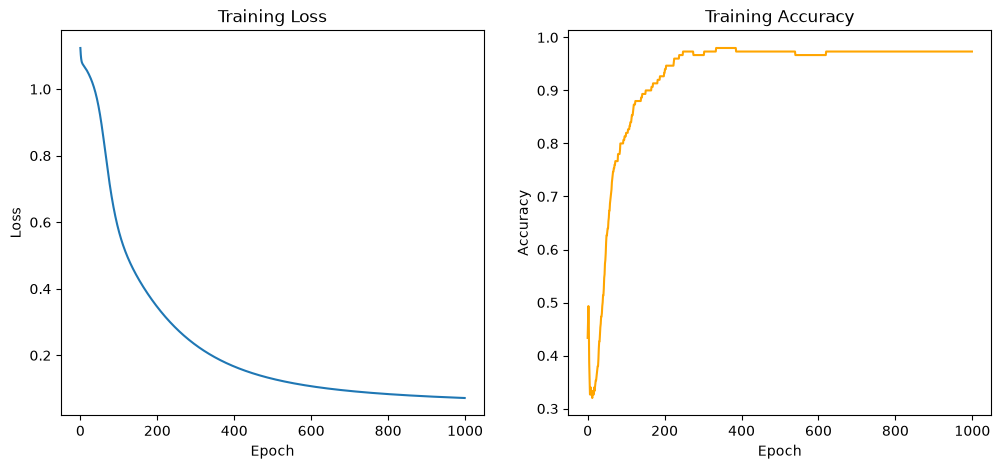

In [19]:
lr = 1e-3
n_iter = 1000

losses = []
accuracy_list = []

for i in range(n_iter):
    display.clear_output(wait=True)
    

    correct = 0
    epoch_loss = 0

    for x_train, y_train in zip(x, y):

        # set the inputs for the hidden layer
        for h in hidden:
            h.set_input(x_train)

        # forward pass
        logits = np.array([o() for o in output])

        # calculate output probabilities
        pred_prob = softmax(logits)

        # get model loss
        loss, upstream = cross_entropy_loss(pred_prob, y_train)

        # print(loss)
        correct += np.argmax(pred_prob) == np.argmax(y_train)
        epoch_loss += loss

        # zero out the gradients
        for o in output:
            o.zero_grad()
        for h in hidden:
            h.zero_grad()

        # backward pass
        dl_do = []
        for o_i, ups in enumerate(upstream):
            dl_do.append(output[o_i].backward(ups))
        do_dnj = np.sum(dl_do, axis=0)

        for h, grad in zip(hidden, do_dnj):
            h.backward(grad)

        # update weights and biases
        for o in output:
            o.step(lr)
        for h in hidden:
            h.step(lr)

    accuracy = correct / 150
    losses.append(epoch_loss / 150)
    accuracy_list.append(accuracy)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.plot(losses)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training Loss')

    ax2.plot(accuracy_list, color='orange')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Training Accuracy')

    plt.show()

In [21]:
# pick a random index from the dataset
idx = np.random.randint(0, 150)
x_test = x[idx]
y_test = y[idx]

for h in hidden:
    h.set_input(x_test)
logits = np.array([o() for o in output])
probs = softmax(logits)
category = np.argmax(probs)

predicted = iris_dataset.target_names[category]
actual = iris_dataset.target_names[np.argmax(y_test)]

print(f"Predicted: {predicted}, Actual: {actual}")

Predicted: versicolor, Actual: versicolor
